In [ ]:
!pip install networkx
!pip install tqdm

#State generation
Over here we show how to define the quantum state generator, based on a Graph. The Graph encodes all the relevant information of the quantum state produced, and can be translated into different optic experiments (Bulk Optics, Integrated Photonics or Entanglement by Path identity). The state can be written as \\
$\phi(w)\approx \sum_m\frac{1}{m!}\left(\sum_{E(G)}w(E)x^\dagger(E)y^\dagger(E)\right)^m$
with G being the graph, E the edge of the graph and $x^\dagger$ a creation operator of a photon in path $x$. Each of the edges will have a color associated to the mode number of the photon on that path. As example for 4 paths (a,b) and 2 modes (0 and 1) a potential state is \\
$\phi(w)= \sum_m\frac{1}{m!}\left(w_{a,b}^{0,0}a_0^\dagger b_0^\dagger + w_{c,d}^{0,0}c_0^\dagger d_0^\dagger + w_{a,c}^{1,1}a_1^\dagger c_1^\dagger  + w_{b,d}^{1,1}b_1^\dagger d_1^\dagger \right)^m  $

For this reason we want to encode this into a graph, which may have potentially more than 1 edge (Correlated Photon pairs) between 2 nodes (Optical paths). As example we will produce the graph with 4 weighted edges, 4 optical paths and it's complete version.

Edge (a, b): color=0, weight=(2+3j)
Edge (a, c): color=1, weight=(1-1j)
Edge (b, d): color=1, weight=(1+1j)
Edge (c, d): color=0, weight=(4+2j)


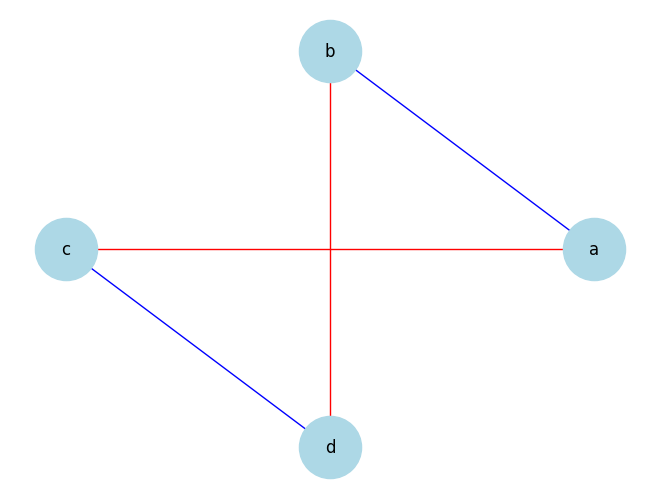

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

#Initial simple empty graph.
G = nx.Graph()
# Add nodes
optical_paths = ['a', 'b', 'c', 'd']
G.add_nodes_from(optical_paths)
#For plotting
color_mapping = {'blue': 0, 'red': 1, 'green': 2, 'yellow': 3, 'purple': 4}
# Define edges with attributes
edges = [
    ('a', 'b', {'color': 0, 'w': 2 + 3j}),
    ('a', 'c', {'color': 1, 'w': 1 - 1j}),
    ('d', 'c', {'color': 0, 'w': 4 + 2j}),
    ('d', 'b', {'color': 1, 'w': 1 + 1j})
]

# Add edges with attributes
G.add_edges_from(edges)

# Verifying edges with attributes
for u, v, data in G.edges(data=True):
    print(f"Edge ({u}, {v}): color={data['color']}, weight={data['w']}")

# Draw the graph
pos = nx.circular_layout(G)
edge_colors = [list(color_mapping.keys())[list(color_mapping.values()).index(data['color'])] for _, _, data in G.edges(data=True)]
nx.draw(G, pos, with_labels=True, edge_color=edge_colors, node_color='lightblue', node_size=2000, font_size=12)
plt.show()


In [ ]:
#If you want to take out the weights from each of the edges to compute the Fidelity:
w_values = [data['w'] for _, _, data in G.edges(data=True)]
print(f"Weights for each edge in the same order they were appended {w_values}")
#And if you want the edges from a particular optical path (Info of entangled photons)
print("Edges connected to node 'a':")
for neighbor in G.neighbors('a'):
    data = G['a'][neighbor]
    print(f"Edge (a, {neighbor}): color={data['color']}, w={data['w']}")

#If you want the specific data for an edge you can do
print(f"Data for edge ('a', 'b'): {G['a']['b']}")
print(f"Color for edge ('a', 'b'): {G['a']['b']['color']}")
print(f"Weight for edge ('a', 'b'): {G['a']['b']['w']}")


Weights for each edge in the same order they were appended [(2+3j), (1-1j), (1+1j), (4+2j)]
Edges connected to node 'a':
Edge (a, b): color=0, w=(2+3j)
Edge (a, c): color=1, w=(1-1j)
Data for edge ('a', 'b'): {'color': 0, 'w': (2+3j)}
Color for edge ('a', 'b'): 0
Weight for edge ('a', 'b'): (2+3j)


Now, we potentially want to generate multiple edges for very complex target states. In that case we want to use a multigraph instead. We will produce the complete graph for the 4 optical path system. For this purpose, the type of object needs to change. Now we are dealing with a MultiGraph, the colors of the edge will be appended as a tuple.

In [ ]:
import itertools as it
#For plotting
def draw_labeled_multigraph(G, attr_name, ax=None):
    """
    Draws a MultiGraph with multi-edges (multiple edges between nodes) and labels the edges
    based on an attribute (e.g., 'w' for weight, 'colors'). Each edge has two colors in this example.
    Based on the example https://networkx.org/documentation/stable/auto_examples/drawing/plot_multigraphs.html
    """
    # Define color mapping for two colors per edge
    color_mapping = {0: 'blue', 1: 'red', 2: 'green', 3: 'yellow', 4: 'purple'}
    #Tried to plot each edge with 2 colors but could not do it. It is better to print the label.
    connectionstyle = [f"arc3,rad={r}" for r in it.accumulate([0.15] * 4)]

    pos = nx.circular_layout(G)  # You can change the layout if needed
    nx.draw_networkx_nodes(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color="grey", connectionstyle=connectionstyle, ax=ax
    )

    # Prepare edge labels
    labels = {
        tuple(edge): f"{edge}, {attr_name}:{attrs[attr_name]}"
        for *edge, attrs in G.edges(keys=True, data=True)
    }
    #labels
    nx.draw_networkx_edge_labels(
        G,
        pos,
        labels,
        connectionstyle=connectionstyle,
        label_pos=0.3,
        font_color="blue",
        bbox={"alpha": 0},
        ax=ax,
    )

Edge (a, b) [0]: colors=(0, 0), w=(4+20j)
Edge (a, b) [1]: colors=(0, 1), w=(6-9j)
Edge (a, b) [2]: colors=(1, 0), w=(1-1j)
Edge (a, b) [3]: colors=(0, 0), w=(4+2j)
Edge (a, c) [0]: colors=(0, 0), w=(1+3j)
Edge (a, c) [1]: colors=(0, 1), w=(1-2j)
Edge (a, c) [2]: colors=(1, 0), w=(4-1j)
Edge (a, c) [3]: colors=(0, 0), w=(7+2j)
Edge (a, d) [0]: colors=(0, 0), w=(8+3j)
Edge (a, d) [1]: colors=(0, 1), w=-2j
Edge (a, d) [2]: colors=(1, 0), w=(1+0j)
Edge (a, d) [3]: colors=(0, 0), w=(4+7j)
Edge (b, c) [0]: colors=(0, 0), w=(1+4j)
Edge (b, c) [1]: colors=(0, 1), w=(3-1j)
Edge (b, c) [2]: colors=(1, 0), w=(1-3j)
Edge (b, c) [3]: colors=(0, 0), w=(5+2j)
Edge (b, d) [0]: colors=(0, 0), w=(1+7j)
Edge (b, d) [1]: colors=(0, 1), w=(9-2j)
Edge (b, d) [2]: colors=(1, 0), w=(1-8j)
Edge (b, d) [3]: colors=(0, 0), w=(6+2j)
Edge (c, d) [0]: colors=(0, 0), w=(7+3j)
Edge (c, d) [1]: colors=(0, 1), w=(3-3j)
Edge (c, d) [2]: colors=(1, 0), w=(1-9j)
Edge (c, d) [3]: colors=(0, 0), w=(6+9j)
Edges connected to

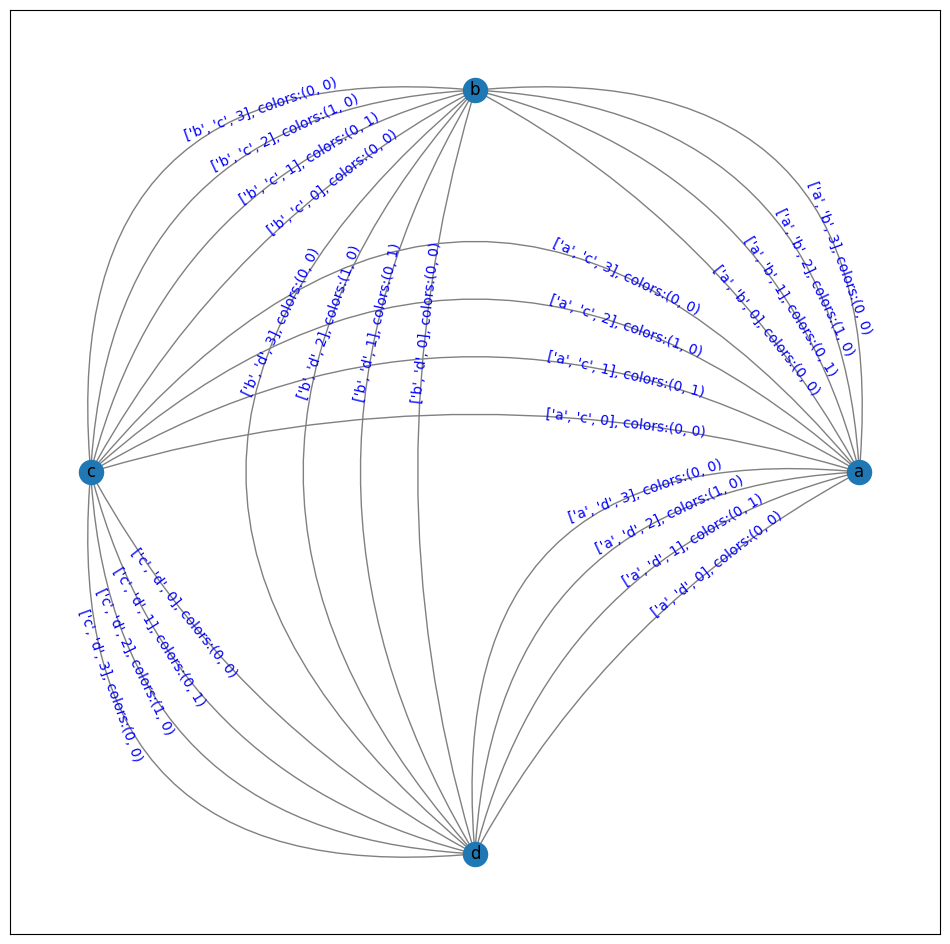

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create an undirected multigraph
G = nx.MultiGraph()

# Add nodes
g_nodes = ['a', 'b', 'c', 'd']
G.add_nodes_from(g_nodes)

# Define color mapping
color_mapping = {0: 'blue', 1: 'red', 2: 'green', 3: 'yellow', 4: 'purple'}

# Define edges with attributes (each edge has two colors)
edges = [
    ('a', 'b', {'colors': (0, 0), 'w': 4 + 20j}),
    ('a', 'b', {'colors': (0, 1), 'w': 6 - 9j}),
    ('a', 'b', {'colors': (1, 0), 'w': 1 - 1j}),
    ('a', 'b', {'colors': (0, 0), 'w': 4 + 2j}),
    ('a', 'c', {'colors': (0, 0), 'w': 1 + 3j}),
    ('a', 'c', {'colors': (0, 1), 'w': 1 - 2j}),
    ('a', 'c', {'colors': (1, 0), 'w': 4 - 1j}),
    ('a', 'c', {'colors': (0, 0), 'w': 7 + 2j}),
    ('a', 'd', {'colors': (0, 0), 'w': 8 + 3j}),
    ('a', 'd', {'colors': (0, 1), 'w': 0 - 2j}),
    ('a', 'd', {'colors': (1, 0), 'w': 1 - 0j}),
    ('a', 'd', {'colors': (0, 0), 'w': 4 + 7j}),
    ('b', 'c', {'colors': (0, 0), 'w': 1 + 4j}),
    ('b', 'c', {'colors': (0, 1), 'w': 3 - 1j}),
    ('b', 'c', {'colors': (1, 0), 'w': 1 - 3j}),
    ('b', 'c', {'colors': (0, 0), 'w': 5 + 2j}),
    ('b', 'd', {'colors': (0, 0), 'w': 1 + 7j}),
    ('b', 'd', {'colors': (0, 1), 'w': 9 - 2j}),
    ('b', 'd', {'colors': (1, 0), 'w': 1 - 8j}),
    ('b', 'd', {'colors': (0, 0), 'w': 6 + 2j}),
    ('c', 'd', {'colors': (0, 0), 'w': 7 + 3j}),
    ('c', 'd', {'colors': (0, 1), 'w': 3 - 3j}),
    ('c', 'd', {'colors': (1, 0), 'w': 1 - 9j}),
    ('c', 'd', {'colors': (0, 0), 'w': 6 + 9j})
]

# Add edges with attributes
G.add_edges_from(edges)

# Print edges with attributes. The keys value tells the total number of edges present.
for u, v, key, data in G.edges(keys=True, data=True):
    print(f"Edge ({u}, {v}) [{key}]: colors={data['colors']}, w={data['w']}")

# Print edges connected to node 'a'
print("Edges connected to node 'a':")
for neighbor in G.neighbors('a'):
    for key in G['a'][neighbor]:
        data = G['a'][neighbor][key]
        print(f"Edge (a, {neighbor}) [{key}]: colors={data['colors']}, w={data['w']}")


# Plot the graph
fig, ax = plt.subplots(figsize=(12, 12))
#draw_labeled_multigraph(G, 'w', ax=ax) #Plots the weights
draw_labeled_multigraph(G, 'colors', ax=ax) #Plots the colors
plt.show()


In [ ]:
#Now getting the data between 2 edges gives a dictionary with the info of all the edges.")
print(f"Data for edge ('a', 'b'): {G['a']['b']}")
#To get the data for a particular key you will need to add the key, since we have multiple
print(f"Data for a particular edge ('a', 'b', [key]): {G['a']['b'][0]}")
#To get the data for either colors or weights you need to add the key or take it from the dictionary
print(f"Color for a particular edge ('a', 'b', [key]): {G['a']['b'][0]['colors']}")

Data for edge ('a', 'b'): {0: {'colors': (0, 0), 'w': (4+20j)}, 1: {'colors': (0, 1), 'w': (6-9j)}, 2: {'colors': (1, 0), 'w': (1-1j)}, 3: {'colors': (0, 0), 'w': (4+2j)}}
Data for a particular edge ('a', 'b', [key]): {'colors': (0, 0), 'w': (4+20j)}
Color for a particular edge ('a', 'b', [key]): (0, 0)


#Let's start training for GFlowNets
We will consider as the set of actions the addition of a weighted colored edge. Each edge contains 2 colors. We will have initially an empty graph with only nodes.

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.distributions.categorical import Categorical
import random

In [ ]:
# Create an undirected multigraph
G = nx.MultiGraph()

# Add nodes
g_nodes = [0, 1, 2, 3]
G.add_nodes_from(g_nodes)
print(G)

MultiGraph with 4 nodes and 0 edges


First implementation considers only colors, since the weights need to be optimized, they are implicit on this graph.

In [ ]:
#Each training step should get a pair of colors and append them to an edge.
#We are going to follow the same procedure as with the smiling faces. Trajectory Balance
#Feature vector is the set of possible edges to generate. (2 colors)

import itertools
from itertools import combinations

# Define number of nodes and colors
num_nodes = 4
num_colors = 2

# Generate all unordered node pairs (without repetition)
node_pairs = list(itertools.combinations(range(num_nodes), 2))

# Generate all possible ordered color pairs (including same colors)
color_pairs = list(itertools.product(range(num_colors), repeat=2))

# Combine each node pair with each color pair
result = [((n1, n2), (c1, c2)) for (n1, n2) in node_pairs for (c1, c2) in color_pairs]
print(len(result))
print("Edges")
print(result[0][0])
print("Colors")
print(result[0][1])
print(result)

24
Edges
(0, 1)
Colors
(0, 0)
[((0, 1), (0, 0)), ((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1), (1, 1)), ((0, 2), (0, 0)), ((0, 2), (0, 1)), ((0, 2), (1, 0)), ((0, 2), (1, 1)), ((0, 3), (0, 0)), ((0, 3), (0, 1)), ((0, 3), (1, 0)), ((0, 3), (1, 1)), ((1, 2), (0, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 0)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 3), (1, 0)), ((1, 3), (1, 1)), ((2, 3), (0, 0)), ((2, 3), (0, 1)), ((2, 3), (1, 0)), ((2, 3), (1, 1))]


In [ ]:
FEATURE_KEYS = [((n1, n2), (c1, c2)) for (n1, n2) in node_pairs for (c1, c2) in color_pairs]
print(FEATURE_KEYS)
print(type(FEATURE_KEYS[0]))
print("FEATURE_KEYS={}".format(FEATURE_KEYS))

[((0, 1), (0, 0)), ((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1), (1, 1)), ((0, 2), (0, 0)), ((0, 2), (0, 1)), ((0, 2), (1, 0)), ((0, 2), (1, 1)), ((0, 3), (0, 0)), ((0, 3), (0, 1)), ((0, 3), (1, 0)), ((0, 3), (1, 1)), ((1, 2), (0, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 0)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 3), (1, 0)), ((1, 3), (1, 1)), ((2, 3), (0, 0)), ((2, 3), (0, 1)), ((2, 3), (1, 0)), ((2, 3), (1, 1))]
<class 'tuple'>
FEATURE_KEYS=[((0, 1), (0, 0)), ((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1), (1, 1)), ((0, 2), (0, 0)), ((0, 2), (0, 1)), ((0, 2), (1, 0)), ((0, 2), (1, 1)), ((0, 3), (0, 0)), ((0, 3), (0, 1)), ((0, 3), (1, 0)), ((0, 3), (1, 1)), ((1, 2), (0, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 0)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 3), (1, 0)), ((1, 3), (1, 1)), ((2, 3), (0, 0)), ((2, 3), (0, 1)), ((2, 3), (1, 0)), ((2, 3), (1, 1))]


In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class TBModel(nn.Module):
  def __init__(self, num_hid):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(len(FEATURE_KEYS), num_hid),  # len(FEATURE_KEYS) input features.
        nn.Tanh(), #nn.LeakyReLU() nn.ReLU()
        nn.Linear(num_hid, 2*len(FEATURE_KEYS)),  # 2*len(FEATURE_KEYS) outputs: len(FEATURE_KEYS) for P_F and len(FEATURE_KEYS) for P_B.
    )
    self.logZ = nn.Parameter(torch.ones(1))  # log Z is just a single number.

  def forward(self, x):
    logits = self.mlp(x)
    # Slice the logits into forward and backward policies.
    P_F = logits[..., :len(FEATURE_KEYS)]
    P_B = logits[..., len(FEATURE_KEYS):]

    return P_F, P_B

def trajectory_balance_loss(logZ, log_P_F, log_P_B, reward):
    """Trajectory balance objective converted into mean squared error loss."""
    reward=torch.tensor(reward).float()
    return (logZ + log_P_F - torch.log(torch.clamp(reward, min=1e-30)) - log_P_B).pow(2)

def state_hash(state):
    """Returns a binary hash for each submitted state."""
    return tuple([i in state for i in FEATURE_KEYS])

def state_to_tensor(state, verbose=False):
  """Encodes a state as a binary tensor (converted to float32)."""
  return torch.tensor(state_hash(state)).float()

def calculate_forward_mask_from_state(state):
    """We want to mask the sampling to avoid any potential loss of time while training.
    If the edge is already on the state, don't add it again. Avoids repeats.
    """
    mask = np.ones(len(FEATURE_KEYS))  # Allowed actions represented as 1, disallowed actions as 0.
    # Update the mask
    for i, edge in enumerate(FEATURE_KEYS):
        if edge in state:
            mask[i] = 0
    return torch.tensor(mask).bool()

def calculate_backward_mask_from_state(state):
    """Here, we mask backward actions to only select parent nodes."""
    # This mask should be 1 for any action that could have led to the current state,
    # otherwise it should be zero.
    return torch.Tensor(
        [1 if feature in state else 0 for feature in FEATURE_KEYS]
    ).bool()

def reward_f(state):
    target_state= [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))]
    reward=0
    for edge in target_state:
        if edge in state:
            reward += 1
    return reward**2
    # if set(state) == set(target_state):
    #     return 10
    # else:
    #     return 0

In [ ]:
#Functions for finding fidelities, just missing the optimization of weights.

def all_perfect_matchings(edge_list):
    # Get total number of unique nodes (ignoring color)
    node_set = set()
    for (u, v), _ in edge_list:
        node_set.update([u, v])

    n = len(node_set)
    if n % 2 != 0:
        return []

    perfect_matchings = []

    # Try all combinations of n/2 edges
    for edge_combo in combinations(edge_list, n // 2):
        used_nodes = set()
        valid = True
        for (u, v), _ in edge_combo:
            if u in used_nodes or v in used_nodes:
                valid = False
                break
            used_nodes.update([u, v])
        if valid:
            perfect_matchings.append(edge_combo)

    return perfect_matchings


def weights(state):
    weight = []
    for a in range(len(state)):
        weight.append(np.random.uniform(0,1))
    return weight

def fidelity(target_state,edges):
    p_m = all_perfect_matchings(edges)
    weight = weights(edges)
    state_ = []
    general_w = []
    #print("state",edges)
    for a in range(len(p_m)):
        string = []

        for b in range(len(p_m[a])):

                    for c in range(num_nodes):
                        if p_m[a][b][0][0]==c:
                            string.append(p_m[a][b][1][0])
                        if p_m[a][b][0][1]==c:
                            string.append(p_m[a][b][1][1])
        state_.append(string)

    for a in range(len(state_)):
        for b in range(len(edges)):
            for c in range(len(edges)):
                if b < c:
                    if len(state_[a]) < len(target_state[0]):
                        return 0.0
                    else:
                        if (state_[a][0],state_[a][1])+(state_[a][2],state_[a][3]) == edges[b][1]+edges[c][1]:

                            if tuple(sorted(edges[b][0] + edges[c][0]))== tuple(range(num_nodes)):
                                general_w.append(weight[b]*weight[c])
    #print("general_w",general_w)
    t_w = []
    for a in range(len(target_state)):
        for b in range(len(state_)):
            if target_state[a] == state_[b]:
                if b < len(general_w): #This
                    t_w.append(general_w[b])
                # else:
                #     print(f"Warning: skipping b={b} due to general_w length {len(general_w)}")

    #print("t_w",t_w)

    if not general_w: #Avoids dividing by 0.
        return 0.0

    F = abs(np.sum(t_w))**2/(abs(np.sum(general_w))**2)
    return F

def reward_fidelity(target_state,state):
    reward = fidelity(target_state,state)
    if np.isnan(reward):
        reward = 0.0
        #print("NAN!")
    return reward

In [ ]:
# Fixed hyperparameters.
n_hid_units = 256
n_episodes = 200
learning_rate = 1e-2
decay_rate = 1#0.9999
seed = 69
max_edges = 4
target_state = [[0,0,0,0],[1,1,1,1]]

print("For all experiments, our hyperparameters will be:")
print("    + n_hid_units={}".format(n_hid_units))
print("    + n_episodes={}".format(n_episodes))
print("    + learning_rate={}".format(learning_rate))
print("    + decay_rate={}".format(decay_rate))
print("    + seed={}".format(seed))
print("    + max_edges={}".format(max_edges))
print("    + target state={}".format(target_state))

For all experiments, our hyperparameters will be:
    + n_hid_units=256
    + n_episodes=200
    + learning_rate=0.01
    + decay_rate=1
    + seed=69
    + max_edges=4
    + target state=[[0, 0, 0, 0], [1, 1, 1, 1]]


Training

In [ ]:
set_seed(seed)

# Instantiate model and optimizer
model = TBModel(n_hid_units)
opt = torch.optim.Adam(model.parameters(), learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=decay_rate)

# To not complicate the code, I'll just accumulate losses here and take a
# gradient step every `update_freq` episode (at the end of each trajectory).
losses, sampled_states, logZs = [], [], []
minibatch_loss = 0
update_freq = 100

for episode in tqdm(range(n_episodes), ncols=40):
    state = []  # Each episode starts with an empty state.
    P_F_s, P_B_s = model(state_to_tensor(state))  # Forward and backward policy
    total_log_P_F, total_log_P_B = 0, 0

    for t in range(max_edges):  # All trajectories are length 2 (not including s0).
        mask = calculate_forward_mask_from_state(state)
        P_F_s = torch.where(mask, P_F_s, -100)  # Removes invalid forward actions.
        # Here P_F is logits, so we use Categorical to compute a softmax.
        #P_F_s = torch.where(torch.isnan(P_F_s), torch.full_like(P_F_s, -100), P_F_s)
        categorical = Categorical(logits=P_F_s)
        action = categorical.sample()
        new_state = state + [FEATURE_KEYS[action]] # "Go" to next state.
        total_log_P_F += categorical.log_prob(action)  # Accumulate the log_P_F sum.

        if t == max_edges-1:  # End of trajectory.
            reward = reward_f(new_state)#torch.tensor(reward(new_state)).float()
            #reward = reward_fidelity(target_state, new_state)
            #print("Reward",reward)
        # We recompute P_F and P_B for new_state.
        P_F_s, P_B_s = model(state_to_tensor(new_state))
        #print(new_state)
        mask = calculate_backward_mask_from_state(new_state)
        P_B_s = torch.where(mask, P_B_s, -100)  # Removes invalid backward actions.
        #P_B_s = torch.where(torch.isnan(P_B_s), torch.full_like(P_B_s, -100), P_B_s)
        total_log_P_B += Categorical(logits=P_B_s).log_prob(action)

        state = new_state  # Continue iterating.

    # We're done with the trajectory, let's compute its loss. Since the reward
    # can sometimes be zero, instead of log(0) we'll clip the log-reward to -20.
    minibatch_loss += trajectory_balance_loss(
        model.logZ,
        total_log_P_F,
        total_log_P_B,
        reward,
    )

    # We're done with the episode, add the face to the list, and if we are at an
    # update episode, take a gradient step.
    sampled_states.append(state)
    if episode % update_freq == 0:
        losses.append(minibatch_loss.item())
        logZs.append(model.logZ.item())
        minibatch_loss.backward()
        opt.step()
        opt.zero_grad()
        scheduler.step()
        minibatch_loss = 0

100%|█| 200/200 [00:01<00:00, 132.79it/s


In [ ]:
# ordered_states = sorted(sampled_states, key=lambda i: reward_fidelity(target_state,i), reverse=True)
# print(reward_fidelity(target_state,ordered_states[0]))

ordered_states = sorted(sampled_states, key=lambda i: reward_f(i), reverse=True)
print(reward_f(ordered_states[0]))

9


In [ ]:
print(ordered_states[0])

[((2, 3), (0, 0)), ((0, 2), (0, 1)), ((0, 1), (0, 0)), ((0, 3), (1, 1))]


In [ ]:
target_state= [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))]
print(target_state)
print(ordered_states[0])
print(set(target_state))
print(set(ordered_states[0]))

[((0, 1), (0, 0)), ((0, 3), (1, 1)), ((1, 2), (1, 1)), ((2, 3), (0, 0))]
[((2, 3), (0, 0)), ((0, 2), (0, 1)), ((0, 1), (0, 0)), ((0, 3), (1, 1))]
{((0, 3), (1, 1)), ((1, 2), (1, 1)), ((2, 3), (0, 0)), ((0, 1), (0, 0))}
{((0, 3), (1, 1)), ((0, 2), (0, 1)), ((2, 3), (0, 0)), ((0, 1), (0, 0))}


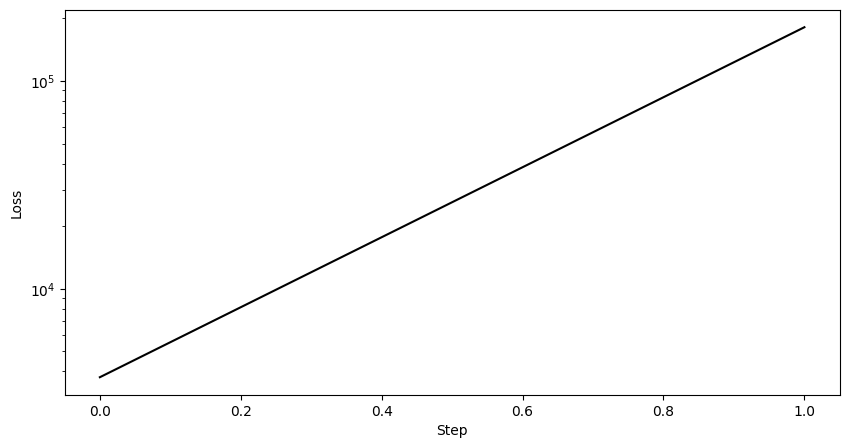

In [ ]:
def plot_loss_curve(figure, losses_A, title=""):
    filename = f"{figure}_loss.svg"
    plt.figure(figsize=(10,5))
    plt.plot(losses_A, color="black")
    plt.yscale("log")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(filename, format='svg', dpi=600)
fig_name="Loss"
plot_loss_curve(fig_name, losses, title="Loss over Training Iterations")

Text(0.5, 0.98, 'Loss and Estimated Partition Function for the Trajectory Balance Model')

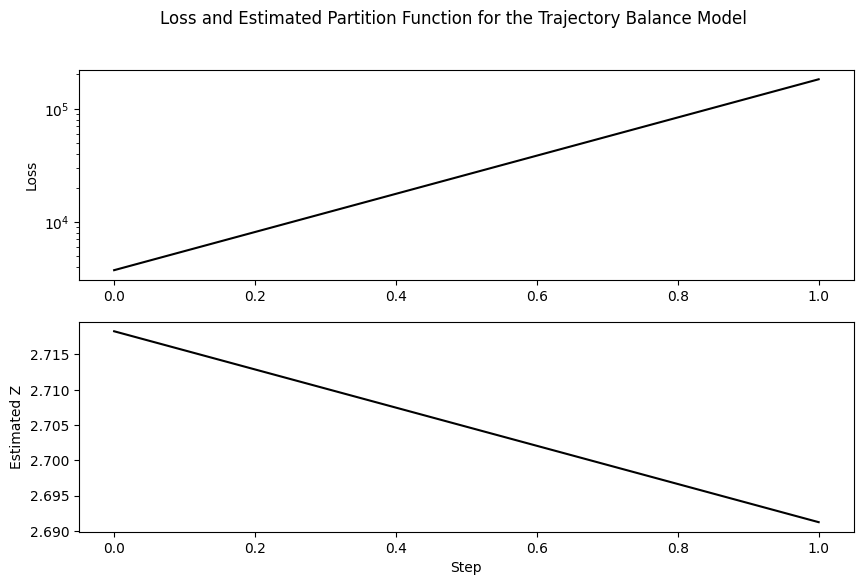

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plt.sca(ax[0])
plt.plot(losses, color="black")
plt.yscale('log')
plt.ylabel('Loss')
plt.sca(ax[1])
plt.plot(np.exp(logZs), color="black")
plt.ylabel('Estimated Z');
plt.xlabel('Step')
plt.suptitle("Loss and Estimated Partition Function for the Trajectory Balance Model")

In [ ]:
print(scheduler.get_last_lr())

[0.01]


In [ ]:
#Example for result vis.
# Create graph
G = nx.MultiGraph()
edge_vec = ordered_states[0] # [((0, 1), (1, 1)), ((0, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 2), (0, 0))]#[((1, 3), (1, 0)), ((2, 3), (0, 0)), ((0, 3), (0, 1)), ((2, 3), (1, 0))] #ordered_states[0]
print(ordered_states[0])
# Add edges with 'colors' attribute
for (a, b), (c1, c2) in edge_vec:
    G.add_edge(a, b, colors=(c1, c2))

print(G)


[((2, 3), (0, 0)), ((0, 2), (0, 1)), ((0, 1), (0, 0)), ((0, 3), (1, 1))]
MultiGraph with 4 nodes and 4 edges


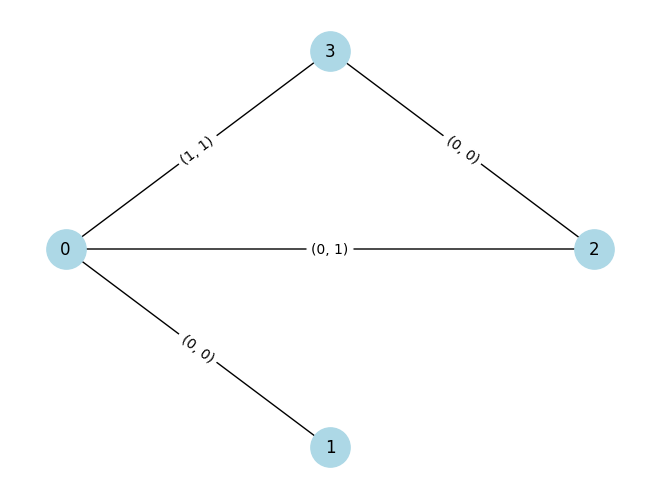

In [ ]:
#This one does not work if there are 2 edges between same nodes.
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=12)
edge_labels = nx.get_edge_attributes(G, 'colors')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

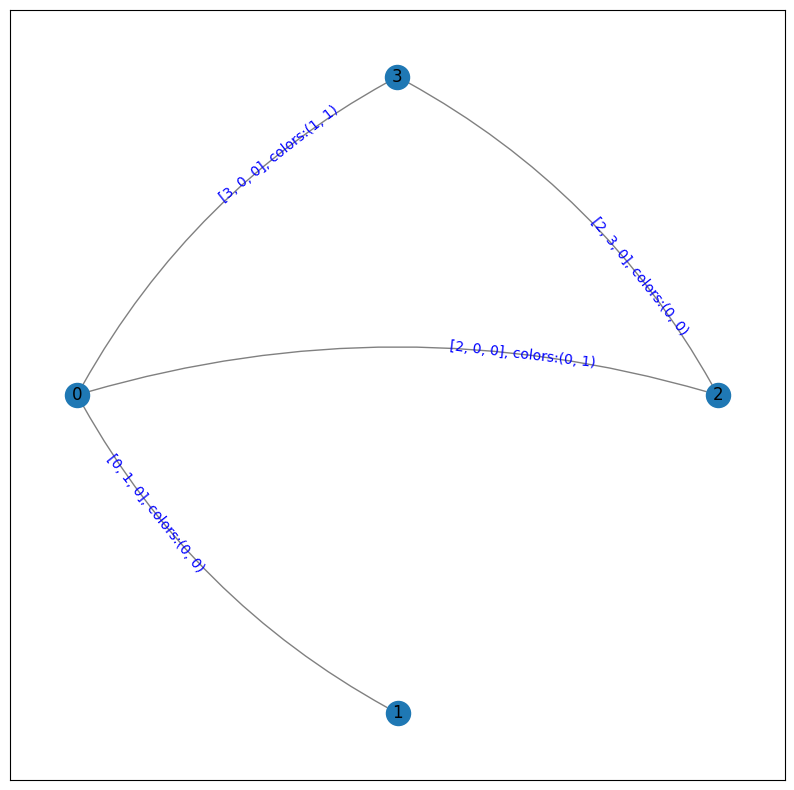

In [ ]:
# Plot the graph
fig, ax = plt.subplots(figsize=(10, 10))
draw_labeled_multigraph(G, 'colors', ax=ax) #Plots the colors
plt.show()

In [ ]:
import itertools

# Define number of nodes and colors
num_nodes = 4
num_colors = 2

#test_state= [((0, 1), (0, 0))] + [((2, 3), (1, 1))] + [((0, 1), (1, 1))] + [((2, 3), (0, 0))] #State with 4 pm's
#test_state = [((1, 2), (1, 1)), ((0, 1), (1, 1)), ((2, 3), (0, 1)), ((0, 3), (1, 0))]
test_state= [((1, 2), (1, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 1)), ((1, 2), (0, 0))]
#test_state =  [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))] #State with 2 pm's
from itertools import combinations
import numpy as np

def all_perfect_matchings(edge_list):
    # Get total number of unique nodes (ignoring color)
    node_set = set()
    for (u, v), _ in edge_list:
        node_set.update([u, v])

    n = len(node_set)
    if n % 2 != 0:
        return []

    perfect_matchings = []

    # Try all combinations of n/2 edges
    for edge_combo in combinations(edge_list, n // 2):
        used_nodes = set()
        valid = True
        for (u, v), _ in edge_combo:
            if u in used_nodes or v in used_nodes:
                valid = False
                break
            used_nodes.update([u, v])
        if valid:
            perfect_matchings.append(edge_combo)

    return perfect_matchings



p_m = all_perfect_matchings(test_state)
state_ = []
weights = []

for a in range(len(p_m)):
    string = []

    for b in range(len(p_m[a])):
                print(p_m[a][b])
                for c in range(num_nodes):
                    if p_m[a][b][0][0]==c:
                        string.append(p_m[a][b][1][0])
                    if p_m[a][b][0][1]==c:
                        string.append(p_m[a][b][1][1])


    state_.append(string)
    #weights.append(1)
    #weights.append(1/np.sqrt(2)) #In principle, Optimal weights for test_state corresponding to Square-Circuit alternating colors (2 pm's)
    weights.append(np.random.uniform(0,1))

target_state = [[0,0,0,0],[1,1,1,1]]
t_w = []
for a in range(len(target_state)):
    for b in range(len(state_)):
        if target_state[a] ==state_[b]:
            t_w.append(weights[b])

F = abs(np.sum(t_w))**2/(abs(np.sum(weights))**2)
print(F,'fidelity')
print(state_)
print('Perfect matchings', p_m)
print(weights)

((1, 2), (1, 0))
((1, 2), (0, 1))
((1, 2), (1, 1))
((1, 2), (0, 0))
0.0 fidelity
[[1, 0], [0, 1], [1, 1], [0, 0]]
Perfect matchings [(((1, 2), (1, 0)),), (((1, 2), (0, 1)),), (((1, 2), (1, 1)),), (((1, 2), (0, 0)),)]
[0.29624916167243354, 0.8090677156733267, 0.35025252522341144, 0.7894092564308925]


In principle the fidelity Should reproduce Eqs B2 and B3 if we add a weight to each edge. https://journals.aps.org/prx/pdf/10.1103/PhysRevX.11.031044

In [ ]:
import itertools

# Define number of nodes and colors
num_nodes = 4
num_colors = 2

#test_state= [((0, 1), (0, 0))] + [((2, 3), (1, 1))] + [((0, 1), (1, 1))] + [((2, 3), (0, 0))] #State with 4 pm's
#test_state =  [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))] #State with 2 pm's
#test_state= [((1, 2), (1, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 1)), ((1, 2), (0, 0))]
test_state = [((0, 1), (1, 1)), ((0, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 2), (0, 0))]

target_state = [[0,0,0,0],[1,1,1,1]]

from itertools import combinations
import numpy as np

def all_perfect_matchings(edge_list):
    # Get total number of unique nodes (ignoring color)
    node_set = set()
    for (u, v), _ in edge_list:
        node_set.update([u, v])

    n = len(node_set)
    if n % 2 != 0:
        return []

    perfect_matchings = []

    # Try all combinations of n/2 edges
    for edge_combo in combinations(edge_list, n // 2):
        used_nodes = set()
        valid = True
        for (u, v), _ in edge_combo:
            if u in used_nodes or v in used_nodes:
                valid = False
                break
            used_nodes.update([u, v])
        if valid:
            perfect_matchings.append(edge_combo)

    return perfect_matchings


def weights(state):
    weight = []
    for a in range(len(state)):
        weight.append(np.random.uniform(0,1))
    return weight

def fidelity(target_state,edges,weight):
    p_m = all_perfect_matchings(edges)
    state_ = []
    general_w = []
    for a in range(len(p_m)):
        string = []

        for b in range(len(p_m[a])):

                    for c in range(num_nodes):
                        if p_m[a][b][0][0]==c:
                            string.append(p_m[a][b][1][0])
                        if p_m[a][b][0][1]==c:
                            string.append(p_m[a][b][1][1])
        state_.append(string)

    for a in range(len(state_)):
        for b in range(len(edges)):
            for c in range(len(edges)):
                if b < c:
                    if (state_[a][0],state_[a][1])+(state_[a][2],state_[a][3]) == edges[b][1]+edges[c][1]:

                        if tuple(sorted(edges[b][0] + edges[c][0]))== tuple(range(num_nodes)):
                            general_w.append(weight[b]*weight[c])

    t_w = []
    for a in range(len(target_state)):
        for b in range(len(state_)):
            if target_state[a] ==state_[b]:
                t_w.append(general_w[b])
    F = abs(np.sum(t_w))**2/(abs(np.sum(general_w))**2)
    return F

w_state= weights(test_state)
F = fidelity(target_state,test_state,w_state)
print('the weights are the following:',w_state)
print(F)

the weights are the following: [0.5613489757705725, 0.25358895422013317, 0.10497708368510905, 0.058460729196879724]
1.0


#Functions to get the quantum state from the perfect matchings.

In [ ]:
#test_state= [((0, 1), (0, 0))] + [((2, 3), (1, 1))] + [((0, 1), (1, 1))] + [((2, 3), (0, 0))] #State with 4 pm's
#test_state =  [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))] #State with 2 pm's
#test_state= [((1, 2), (1, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 1)), ((1, 2), (0, 0))]
test_state = [((0, 1), (0, 0)), ((2, 3), (0, 0)), ((0, 2), (0, 0)), ((1, 3), (0, 0)), ((0, 3), (0, 0)),((1, 2), (0, 0))] #For testing that it works properly

print(test_state)
w_vec=[1,2,3,4,5,6]#weights(test_state)
print(w_vec)
#target_state = [[0,0,0,0],[1,1,1,1]]


[((0, 1), (0, 0)), ((2, 3), (0, 0)), ((0, 2), (0, 0)), ((1, 3), (0, 0)), ((0, 3), (0, 0)), ((1, 2), (0, 0))]
[1, 2, 3, 4, 5, 6]


In [ ]:
pms = all_perfect_matchings(test_state)
print(pms)
print(len(pms))


[(((0, 1), (0, 0)), ((2, 3), (0, 0))), (((0, 2), (0, 0)), ((1, 3), (0, 0))), (((0, 3), (0, 0)), ((1, 2), (0, 0)))]
3


In [ ]:
import numpy as np
from itertools import combinations

def matching_to_state(matching, state, weights):
    n_nodes = num_nodes#max(max(u, v) for ((u, v), _) in state) + 1
    #print(n_nodes)
    #print(state)
    #print(weights)
    colors = [-1] * n_nodes  # placeholder for node colors

    weight_product = 1.0
    for edge in matching:
        (u, v), (cu, cv) = edge

        # Assign colors
        colors[u] = cu
        colors[v] = cv

        # Find the exact match index in state using full edge match
        for i, edge_state in enumerate(state):
            if edge == edge_state:
                weight_product *= weights[i]
                break
        else:
            raise ValueError(f"Edge {edge} not found in original state!")

    return weight_product, tuple(colors)

for i, pm in enumerate(pms):
    amp, basis_state = matching_to_state(pm, test_state, w_vec)
    print(f"PM {i}: amplitude = {amp}, quantum state = |{','.join(map(str, basis_state))}>")
#This will give -1s if the state does not have the correct number of particles. Building the normalized state will give an error which is handled by the optimizer

PM 0: amplitude = 2.0, quantum state = |0,0,0,0>
PM 1: amplitude = 12.0, quantum state = |0,0,0,0>
PM 2: amplitude = 30.0, quantum state = |0,0,0,0>


In [ ]:
import numpy as np
from itertools import combinations

def basis_index(color_tuple):
    return int("".join(str(c) for c in color_tuple), 2)

def build_normalized_state(state, weights):
    matchings = all_perfect_matchings(state)
    n_nodes = max(max(u, v) for ((u, v), _) in state) + 1
    vec_len = num_colors**n_nodes #Size of hilbert space spanned by nodes and modes.
    state_vector = np.zeros(vec_len, dtype=complex)

    for pm in matchings:
        amp, color_state = matching_to_state(pm, state, weights)
        idx = basis_index(color_state)
        state_vector[idx] += amp

    # Normalize
    norm = np.linalg.norm(state_vector)
    if norm == 0:
        raise ValueError("Resulting state vector has zero norm.")
    return state_vector / norm

normalized_state = build_normalized_state(test_state, w_vec)
print(normalized_state)

[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [ ]:
# def state_vector_to_dirac_notation(state_vector, tol=1e-16):
#     terms = []
#     n_qubits = int(np.log2(len(state_vector)))
#     for i, amplitude in enumerate(state_vector):
#         if abs(amplitude) > tol:
#             basis_state = format(i, f"0{n_qubits}b")
#             amp_str = f"{amplitude:.6g}"
#             terms.append(f"{amp_str}|{basis_state}⟩")
#     return " + ".join(terms)

# print(state_vector_to_dirac_notation(normalized_state))

def state_vector_to_dirac_notation(state_vector, n_nodes, num_colors, tol=1e-16):
    terms = []
    for i, amplitude in enumerate(state_vector):
        if abs(amplitude) > tol:
            # Convert index i to base `num_colors` with `n_nodes` digits
            digits = []
            val = i
            for _ in range(n_nodes):
                digits.append(str(val % num_colors))
                val //= num_colors
            basis_state = ''.join(reversed(digits)).rjust(n_nodes, '0')
            amp_str = f"{amplitude:.6g}"
            terms.append(f"{amp_str}|{basis_state}⟩")
    return " + ".join(terms)

In [ ]:
import numpy as np
import re
from sympy import sympify, sqrt

def parse_dirac_expression(expr, num_nodes, num_colors ):
    """
    Parse expressions like '1|0000⟩ + 1|1111⟩' or '1/sqrt(2)|0000⟩' into a normalized NumPy vector.
    """
    expr = expr.replace("⟩", "").replace(" ", "")
    terms = re.findall(r'([^\+]+?\|[0-9]+)', expr) #re.findall(r'([^\+]+?\|[01]+)', expr) #Bug! This assumes binary! Solved.

    if not terms:
        raise ValueError("Invalid expression or format.")

    amplitudes = {}
    for term in terms:
        match = re.match(r'([^|]+)\|([0-9]+)', term)
        if not match:
            raise ValueError(f"Invalid term: {term}")
        coef_str, basis = match.groups()
        coef_val = complex(sympify(coef_str).evalf())
        amplitudes[basis] = coef_val
    dim = num_colors ** num_nodes
    vec = np.zeros(dim, dtype=complex)

    for digits, amplitude in amplitudes.items():
        if len(digits) != num_nodes:
            raise ValueError(f"Basis state length {len(digits)} does not match num_nodes={num_nodes}")
        if any(int(d) >= num_colors for d in digits):
            raise ValueError(f"Digit in basis state {digits} exceeds allowed num_colors={num_colors}")
        index = int(digits, base=num_colors)
        vec[index] = amplitude

    # Normalize
    norm = np.linalg.norm(vec)
    if norm == 0:
        raise ValueError("Zero-norm state.")
    return vec / norm
    #Old version, only works for binary :(
    # for bitstring, amplitude in amplitudes.items():
    #     index = int(bitstring, 2)
    #     vec[index] = amplitude

    # # Normalize
    # norm = np.linalg.norm(vec)
    # if norm == 0:
    #     raise ValueError("Zero-norm state.")
    # return vec / norm

In [ ]:
target_expr = "1|0000⟩ + 1|1111⟩"
target_state = parse_dirac_expression(target_expr,4,2)
print(target_state)
# Overlap with previously built normalized_state,
#IF THE STATE DOES NOT HAVE THE SAME LENGTH THIS GIVES ERROR WHICH IS HANDLED BY OPTIMIZER.
overlap = np.vdot(target_state, normalized_state)
fidelity = abs(overlap)**2

print("Target state:", state_vector_to_dirac_notation(target_state, num_nodes, num_colors))
print(f"Overlap: {overlap}")
print(f"Fidelity: {fidelity}")

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Target state: 0.707107+0j|0000⟩ + 0.707107+0j|1111⟩
Overlap: (0.7071067811865475+0j)
Fidelity: 0.4999999999999999


#Now we optimize the weights

In [ ]:
from scipy.optimize import minimize

def fidelity_objective(weights, state, target_state):
    try:
        normalized = build_normalized_state(state, weights)
        overlap = np.vdot(target_state, normalized)
        fidelity = abs(overlap)**2
        return -fidelity  # we minimize, so negate
    except Exception as e:
        #print("Error during fidelity evaluation:", e)
        return 0.1  # penalty for failure

In [ ]:
#test_state =  [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))] #State with 2 pm's to test that we recover F=1

target_expr = "1|0000⟩ + 1|1111⟩"
target_state = parse_dirac_expression(target_expr,4,2)

# Initial weights
init_weights = np.random.uniform(0, 1, len(test_state))

# Optimize
result = minimize(
    fidelity_objective,
    init_weights,
    args=(test_state, target_state),
    method='L-BFGS-B',
    bounds=[(0, 1)] * len(test_state),
    options={'disp': True}
)

# Optimized weights
opt_weights = result.x
opt_fidelity = -result.fun

print("\nOptimized Weights:", opt_weights)
print("Max Fidelity:", opt_fidelity)


Optimized Weights: [0.67329238 0.69782966 0.73278321 0.78787406 0.07637632 0.3176806 ]
Max Fidelity: 0.4999999999999999


Other optimizer in case we run into errors

In [ ]:
from scipy.optimize import differential_evolution

result = differential_evolution(
    lambda w: fidelity_objective(w, test_state, target_state),
    bounds=[(0, 1)] * len(test_state),
    strategy='best1bin',
    maxiter=200,
    polish=True
)

In [ ]:
print(result.x)
print(-result.fun)

[0.36064596 0.52047335 0.34570305 0.66878125 0.36147602 0.53277189]
0.4999999999999999


In [ ]:
def reward_fidelity(target_state,state):
    """This reward function computes the optimal weights and fidelities. Returns squared of fidelity if the state is valid."""
    # Initial weights
    init_weights = np.random.uniform(0, 1, len(state))

    # Optimize
    result = minimize(
        fidelity_objective,
        init_weights,
        args=(state, target_state),
        method='L-BFGS-B',
        bounds=[(0, 1)] * len(state),
        options={'disp': True}
    )
    # Optimized weights
    opt_weights = result.x
    opt_fidelity = -result.fun

    if opt_fidelity < 0:
        return 0#opt_fidelity
    else:
        return np.exp(opt_fidelity/2)#**2
    #return opt_fidelity

In [ ]:
#test_state= [((0, 1), (0, 0))] + [((2, 3), (1, 1))] + [((0, 1), (1, 1))] + [((2, 3), (0, 0))] #State with 4 pm's
true_state =  [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))] #State with 2 pm's
#test_state= [((1, 2), (1, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 1)), ((1, 2), (0, 0))]
#test_state = [((0, 1), (1, 1)), ((0, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 2), (0, 0))]
print(reward_fidelity(target_state,test_state))
print(reward_fidelity(target_state,true_state))

1.2840254166877414
1.648721270700128


#New training

In [ ]:
import numpy as np
import torch
import re
from sympy import sympify

def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class TBModel(nn.Module):
  def __init__(self, num_hid):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(len(FEATURE_KEYS), num_hid),  # len(FEATURE_KEYS) input features.
        nn.Tanh(), #nn.LeakyReLU() nn.ReLU()
        nn.Linear(num_hid, 2*len(FEATURE_KEYS)),  # 2*len(FEATURE_KEYS) outputs: len(FEATURE_KEYS) for P_F and len(FEATURE_KEYS) for P_B.
    )
    self.logZ = nn.Parameter(torch.ones(1))  # log Z is just a single number.

  def forward(self, x):
    logits = self.mlp(x)
    # Slice the logits into forward and backward policies.
    P_F = logits[..., :len(FEATURE_KEYS)]
    P_B = logits[..., len(FEATURE_KEYS):]

    return P_F, P_B

def trajectory_balance_loss(logZ, log_P_F, log_P_B, reward):
    """Trajectory balance objective converted into mean squared error loss."""
    reward=torch.tensor(reward).float()
    return (logZ + log_P_F - torch.log(torch.clamp(reward, min=1e-30)) - log_P_B).pow(2)

def state_hash(state):
    """Returns a binary hash for each submitted state."""
    return tuple([i in state for i in FEATURE_KEYS])

def state_to_tensor(state, verbose=False):
  """Encodes a state as a binary tensor (converted to float32)."""
  return torch.tensor(state_hash(state)).float()

###IMPROVED FORWARD MASK!!!!
def extract_basis_strings(target_expr):
    target_expr = target_expr.replace("⟩", "").replace(" ", "")
    terms = re.findall(r'([^\+]+?\|[0-9]+)', target_expr)
    basis_strings = []
    for term in terms:
        match = re.match(r'([^|]+)\|([0-9]+)', term)
        if match:
            _, bitstring = match.groups()
            basis_strings.append(bitstring)
    return basis_strings

def calculate_forward_mask_from_state(state, target_expr):
    mask = np.ones(len(FEATURE_KEYS))  # 1 = allowed, 0 = masked

    basis_strings = extract_basis_strings(target_expr)

    for i, edge in enumerate(FEATURE_KEYS):
        # Rule 1: already in state → disallowed
        if edge in state:
            mask[i] = 0
            continue

        (n1, n2), (c1, c2) = edge
        compatible = False
        for bitstring in basis_strings:
            if len(bitstring) <= max(n1, n2):
                continue  # Skip if bitstring is shorter than required node positions
            if int(bitstring[n1]) == c1 and int(bitstring[n2]) == c2:
                compatible = True
                break

        if not compatible:
            mask[i] = 0  # Rule 2: incompatible with target expression

    return torch.tensor(mask).bool()
#OLD VERSION
# def calculate_forward_mask_from_state(state):
#     """We want to mask the sampling to avoid any potential loss of time while training.
#     If the edge is already on the state, don't add it again. Avoids repeats.
#     """
#     mask = np.ones(len(FEATURE_KEYS))  # Allowed actions represented as 1, disallowed actions as 0.
#     # Update the mask
#     for i, edge in enumerate(FEATURE_KEYS):
#         if edge in state:
#             mask[i] = 0
#     return torch.tensor(mask).bool()


def calculate_backward_mask_from_state(state):
    """Here, we mask backward actions to only select parent nodes."""
    # This mask should be 1 for any action that could have led to the current state,
    # otherwise it should be zero.
    return torch.Tensor(
        [1 if feature in state else 0 for feature in FEATURE_KEYS]
    ).bool()

Now that we tested that it works and for invalid states gives an error, wwe can proceed with GFlowNets training.

In [ ]:
#Each training step should get a pair of colors and append them to an edge.
#We are going to follow the same procedure as with the smiling faces. Trajectory Balance
#Feature vector is the set of possible edges to generate. (2 colors)

import itertools
from itertools import combinations

# Define number of nodes and colors
num_nodes = 6
num_colors = 3

# Generate all unordered node pairs (without repetition)
node_pairs = list(itertools.combinations(range(num_nodes), 2))

# Generate all possible ordered color pairs (including same colors)
color_pairs = list(itertools.product(range(num_colors), repeat=2))

# Combine each node pair with each color pair
result = [((n1, n2), (c1, c2)) for (n1, n2) in node_pairs for (c1, c2) in color_pairs]
print(len(result))

135


In [ ]:
FEATURE_KEYS = [((n1, n2), (c1, c2)) for (n1, n2) in node_pairs for (c1, c2) in color_pairs]
#print(FEATURE_KEYS)
#print(type(FEATURE_KEYS[0]))
print("FEATURE_KEYS={}".format(len(FEATURE_KEYS)))

FEATURE_KEYS=135


In [ ]:
# Fixed hyperparameters.
n_hid_units = 512
n_episodes = 200000
learning_rate = 1e-2
decay_rate = 1.00
seed = 666
max_edges = 9
#target_expr = "1|0000⟩ + 1|1111⟩" #4D-GHZ
target_expr = "1|000000⟩ + 1|111111⟩+ 1|222222⟩" #6D-GHZ
target_state = parse_dirac_expression(target_expr, num_nodes, num_colors)

print("For all experiments, our hyperparameters will be:")
print("    + n_hid_units={}".format(n_hid_units))
print("    + n_episodes={}".format(n_episodes))
print("    + learning_rate={}".format(learning_rate))
print("    + decay_rate={}".format(decay_rate))
print("    + seed={}".format(seed))
print("    + max_edges={}".format(max_edges))
#print("    + target state={}".format(target_state))
print("    + Target state:", state_vector_to_dirac_notation(target_state, num_nodes, num_colors))

For all experiments, our hyperparameters will be:
    + n_hid_units=512
    + n_episodes=200000
    + learning_rate=0.01
    + decay_rate=1.0
    + seed=666
    + max_edges=9
    + Target state: 0.57735+0j|000000⟩ + 0.57735+0j|111111⟩ + 0.57735+0j|222222⟩


Training!

In [ ]:
set_seed(seed)

# Instantiate model and optimizer
model = TBModel(n_hid_units)
opt = torch.optim.Adam(model.parameters(), learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=decay_rate)

# To not complicate the code, I'll just accumulate losses here and take a
# gradient step every `update_freq` episode (at the end of each trajectory).
losses, sampled_states, logZs = [], [], []
minibatch_loss = 0
update_freq = 50

for episode in tqdm(range(n_episodes), ncols=40):
    state = []  # Each episode starts with an empty state.
    P_F_s, P_B_s = model(state_to_tensor(state))  # Forward and backward policy
    total_log_P_F, total_log_P_B = 0, 0

    for t in range(max_edges):  # All trajectories are length 2 (not including s0).
        mask = calculate_forward_mask_from_state(state,target_expr)#calculate_forward_mask_from_state(state)
        P_F_s = torch.where(mask, P_F_s, -100)  # Removes invalid forward actions.
        # Here P_F is logits, so we use Categorical to compute a softmax.
        #P_F_s = torch.where(torch.isnan(P_F_s), torch.full_like(P_F_s, -100), P_F_s)
        categorical = Categorical(logits=P_F_s)
        action = categorical.sample()
        new_state = state + [FEATURE_KEYS[action]] # "Go" to next state.
        total_log_P_F += categorical.log_prob(action)  # Accumulate the log_P_F sum.

        if t == max_edges-1:  # End of trajectory.
            #reward = reward_f(new_state)#torch.tensor(reward(new_state)).float()
            reward = reward_fidelity(target_state, new_state)
            #print("Reward",reward)
        # We recompute P_F and P_B for new_state.
        P_F_s, P_B_s = model(state_to_tensor(new_state))
        #print(new_state)
        mask = calculate_backward_mask_from_state(new_state)
        P_B_s = torch.where(mask, P_B_s, -100)  # Removes invalid backward actions.
        #P_B_s = torch.where(torch.isnan(P_B_s), torch.full_like(P_B_s, -100), P_B_s)
        total_log_P_B += Categorical(logits=P_B_s).log_prob(action)

        state = new_state  # Continue iterating.

    # We're done with the trajectory, let's compute its loss. Since the reward
    # can sometimes be zero, instead of log(0) we'll clip the log-reward to -20.
    minibatch_loss += trajectory_balance_loss(
        model.logZ,
        total_log_P_F,
        total_log_P_B,
        reward,
    )

    # We're done with the episode, add the face to the list, and if we are at an
    # update episode, take a gradient step.
    sampled_states.append(state)
    if episode % update_freq == 0:
        losses.append(minibatch_loss.item())
        logZs.append(model.logZ.item())
        minibatch_loss.backward()
        opt.step()
        opt.zero_grad()
        scheduler.step()
        minibatch_loss = 0

100%|█| 200000/200000 [2:00:26<00:00, 27


In [ ]:
print("Last LR",scheduler.get_last_lr())

Last LR [0.01]


In [ ]:
ordered_states = sorted(sampled_states, key=lambda i: reward_fidelity(target_state,i), reverse=True)
print(reward_fidelity(target_state,ordered_states[0]))

1.181360412865646


In [ ]:
print(ordered_states[0])
print(set(ordered_states[0]))

[((1, 2), (0, 0)), ((3, 4), (1, 1)), ((1, 4), (2, 2)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((2, 4), (0, 0)), ((1, 5), (0, 0)), ((2, 3), (2, 2)), ((0, 3), (0, 0))]
{((1, 3), (0, 0)), ((1, 2), (0, 0)), ((0, 3), (0, 0)), ((1, 4), (2, 2)), ((2, 4), (0, 0)), ((1, 5), (0, 0)), ((1, 2), (1, 1)), ((2, 3), (2, 2)), ((3, 4), (1, 1))}


Text(0.5, 0.98, 'Loss and Estimated Partition Function for the Trajectory Balance Model')

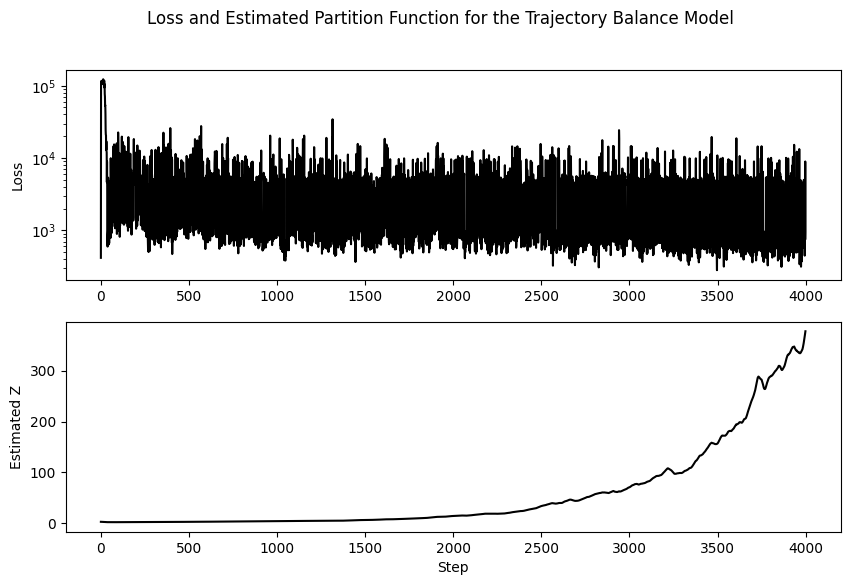

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plt.sca(ax[0])
plt.plot(losses, color="black")
plt.yscale('log')
plt.ylabel('Loss')
plt.sca(ax[1])
plt.plot(np.exp(logZs), color="black")
plt.ylabel('Estimated Z');
plt.xlabel('Step')
plt.suptitle("Loss and Estimated Partition Function for the Trajectory Balance Model")

In [ ]:
#Example for result vis.
# Create graph
G = nx.MultiGraph()
edge_vec = ordered_states[0] # [((0, 1), (1, 1)), ((0, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 2), (0, 0))]#[((1, 3), (1, 0)), ((2, 3), (0, 0)), ((0, 3), (0, 1)), ((2, 3), (1, 0))] #ordered_states[0]
print(edge_vec)
# Add edges with 'colors' attribute
for (a, b), (c1, c2) in edge_vec:
    G.add_edge(a, b, colors=(c1, c2))

print(G)

[((1, 2), (0, 0)), ((3, 4), (1, 1)), ((1, 4), (2, 2)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((2, 4), (0, 0)), ((1, 5), (0, 0)), ((2, 3), (2, 2)), ((0, 3), (0, 0))]
MultiGraph with 6 nodes and 9 edges


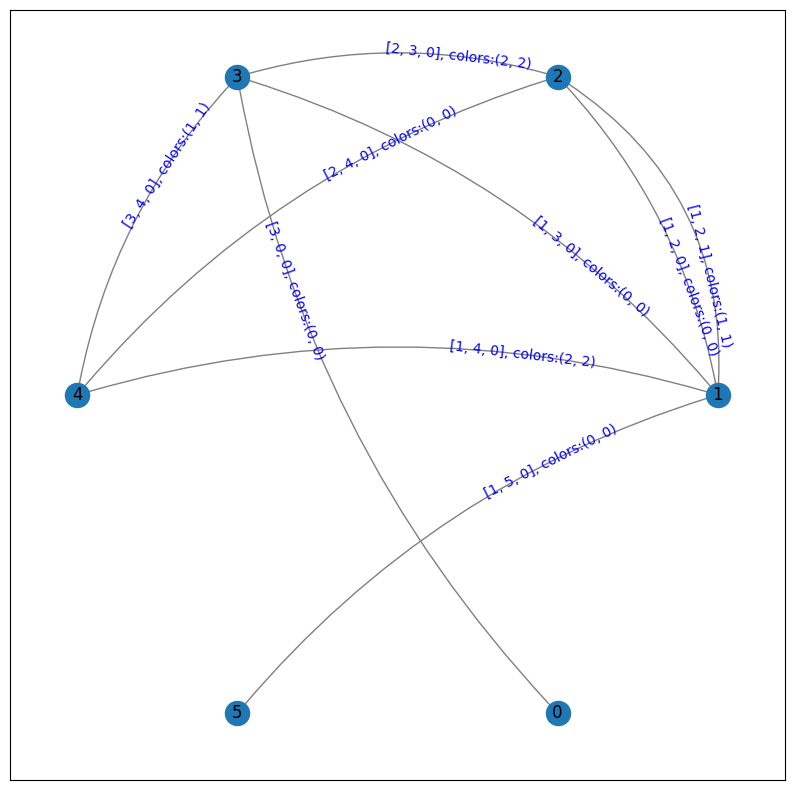

In [ ]:
# Plot the graph
fig, ax = plt.subplots(figsize=(10, 10))
draw_labeled_multigraph(G, 'colors', ax=ax) #Plots the colors
plt.show()

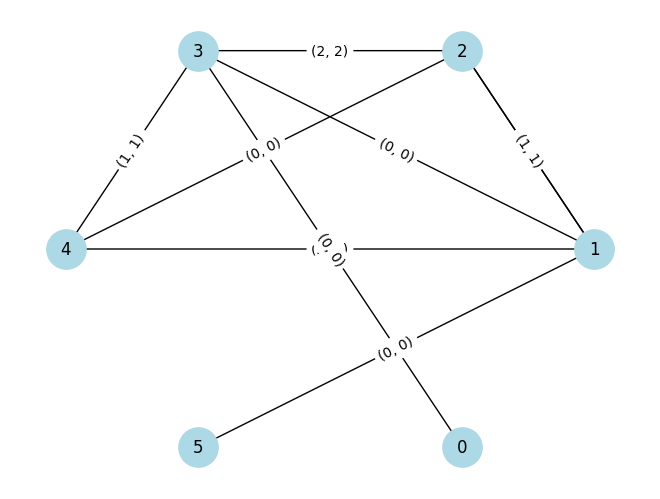

In [ ]:
#This one does not work if there are 2 edges between same nodes.
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=12)
edge_labels = nx.get_edge_attributes(G, 'colors')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Compute reward fidelities
fidelities = [reward_fidelity(target_state, s) for s in ordered_states]

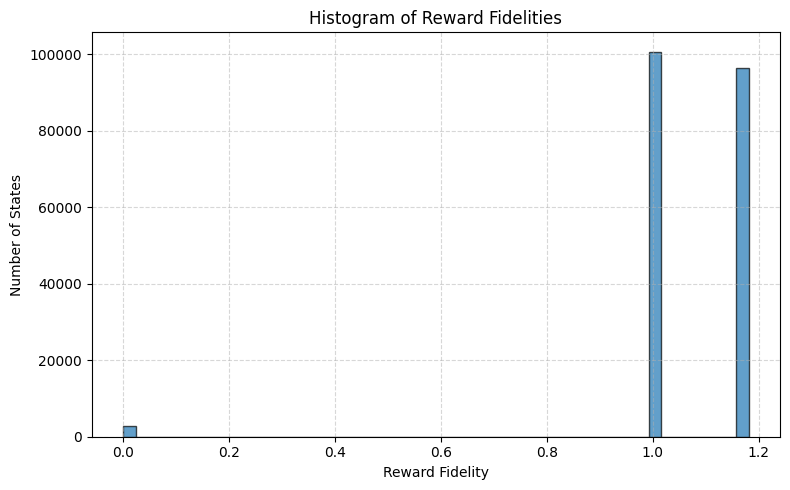

In [ ]:
# Step 2: Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(fidelities, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Reward Fidelity')
plt.ylabel('Number of States')
plt.title('Histogram of Reward Fidelities')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Improved masking function.

We can improve on the masking function. Given a string for a target state, we want to avoid any possible edge with colors that are incompatible. I.e. for the target state with $|0,0,0,0\rangle +|1,1,1,1\rangle$ it does not make sense to add states that won't generate perfect matchings. For example, the edge [(node_1,node_2),(color_1,color_2)] → [(0,1),(0,1)] can't produce any of the possible target quantum states. The masking function will then read the target state, and if the FEATURE_KEY contains an incompatible item, it won't be added.

In [ ]:
def calculate_forward_mask_from_state(state):
    """We want to mask the sampling to avoid any potential loss of time while training.
    If the edge is already on the state, don't add it again. Avoids repeats.
    """
    mask = np.ones(len(FEATURE_KEYS))  # Allowed actions represented as 1, disallowed actions as 0.
    # Update the mask
    for i, edge in enumerate(FEATURE_KEYS):
        if edge in state:
            mask[i] = 0
    return torch.tensor(mask).bool()

print(calculate_forward_mask_from_state(ordered_states[0]))

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True,  True,  True, False,
         True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True, False,
        False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True, 

In [ ]:
import numpy as np
import torch
import re
from sympy import sympify

def extract_basis_strings(target_expr):
    target_expr = target_expr.replace("⟩", "").replace(" ", "")
    terms = re.findall(r'([^\+]+?\|[0-9]+)', target_expr)
    basis_strings = []
    for term in terms:
        match = re.match(r'([^|]+)\|([0-9]+)', term)
        if match:
            _, bitstring = match.groups()
            basis_strings.append(bitstring)
    return basis_strings

def calculate_forward_mask_from_state(state, target_expr):
    mask = np.ones(len(FEATURE_KEYS))  # 1 = allowed, 0 = masked

    basis_strings = extract_basis_strings(target_expr)

    for i, edge in enumerate(FEATURE_KEYS):
        # Rule 1: already in state → disallowed
        if edge in state:
            mask[i] = 0
            continue

        (n1, n2), (c1, c2) = edge
        compatible = False
        for bitstring in basis_strings:
            if len(bitstring) <= max(n1, n2):
                continue  # Skip if bitstring is shorter than required node positions
            if int(bitstring[n1]) == c1 and int(bitstring[n2]) == c2:
                compatible = True
                break

        if not compatible:
            mask[i] = 0  # Rule 2: incompatible with target expression

    return torch.tensor(mask).bool()

In [ ]:
print(ordered_states[0])
print(calculate_forward_mask_from_state(ordered_states[0],target_expr))
print(calculate_forward_mask_from_state([],target_expr))

[((1, 2), (0, 0)), ((3, 4), (1, 1)), ((1, 4), (2, 2)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((2, 4), (0, 0)), ((1, 5), (0, 0)), ((2, 3), (2, 2)), ((0, 3), (0, 0))]
tensor([ True, False, False, False,  True, False, False, False,  True,  True,
        False, False, False,  True, False, False, False,  True, False, False,
        False, False,  True, False, False, False,  True,  True, False, False,
        False,  True, False, False, False,  True,  True, False, False, False,
         True, False, False, False,  True, False, False, False, False, False,
        False, False, False,  True, False, False, False, False,  True, False,
        False, False,  True,  True, False, False, False,  True, False, False,
        False, False, False, False, False, False,  True, False, False, False,
         True,  True, False, False, False,  True, False, False, False, False,
        False, False, False, False,  True, False, False, False,  True,  True,
        False, False, False,  True, False, False, False, 

In [ ]:
print(calculate_backward_mask_from_state(ordered_states[0]))
print(calculate_backward_mask_from_state([]))

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False,  True,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False,  True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,  True,
         True, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

In [ ]:
for i in range(len(FEATURE_KEYS)):
    print(FEATURE_KEYS[i])

((0, 1), (0, 0))
((0, 1), (0, 1))
((0, 1), (0, 2))
((0, 1), (1, 0))
((0, 1), (1, 1))
((0, 1), (1, 2))
((0, 1), (2, 0))
((0, 1), (2, 1))
((0, 1), (2, 2))
((0, 2), (0, 0))
((0, 2), (0, 1))
((0, 2), (0, 2))
((0, 2), (1, 0))
((0, 2), (1, 1))
((0, 2), (1, 2))
((0, 2), (2, 0))
((0, 2), (2, 1))
((0, 2), (2, 2))
((0, 3), (0, 0))
((0, 3), (0, 1))
((0, 3), (0, 2))
((0, 3), (1, 0))
((0, 3), (1, 1))
((0, 3), (1, 2))
((0, 3), (2, 0))
((0, 3), (2, 1))
((0, 3), (2, 2))
((0, 4), (0, 0))
((0, 4), (0, 1))
((0, 4), (0, 2))
((0, 4), (1, 0))
((0, 4), (1, 1))
((0, 4), (1, 2))
((0, 4), (2, 0))
((0, 4), (2, 1))
((0, 4), (2, 2))
((0, 5), (0, 0))
((0, 5), (0, 1))
((0, 5), (0, 2))
((0, 5), (1, 0))
((0, 5), (1, 1))
((0, 5), (1, 2))
((0, 5), (2, 0))
((0, 5), (2, 1))
((0, 5), (2, 2))
((1, 2), (0, 0))
((1, 2), (0, 1))
((1, 2), (0, 2))
((1, 2), (1, 0))
((1, 2), (1, 1))
((1, 2), (1, 2))
((1, 2), (2, 0))
((1, 2), (2, 1))
((1, 2), (2, 2))
((1, 3), (0, 0))
((1, 3), (0, 1))
((1, 3), (0, 2))
((1, 3), (1, 0))
((1, 3), (1, 1

In [ ]:
print(extract_basis_strings(target_expr))